# NeuroShield Track 1 — Alzheimer's Disease Classification
## Model B — Vision Transformer (ViT-B/16)


## Table of Contents
- [1. Dataset & Preprocessing](#1.-Dataset-&-Preprocessing)
- [2. Model Architecture](#2.-Model-Architecture)
- [3. Sanity Overfit Test](#3.-Sanity-Overfit-Test)
- [4. Training](#4.-Training)
- [5. Final Test Evaluation](#5.-Final-Test-Evaluation)
- [6. Final Results](#6.-Final-Results)
- [7. Saved Artifacts & Configuration](#7.-Saved-Artifacts-&-Configuration)
- [8. Experiment Summary](#8.-Experiment-Summary)


In [1]:
import os

INPUT_DIR = "/kaggle/input"

# Find the attached dataset
datasets = os.listdir(INPUT_DIR)

print("Datasets attached to this notebook:")
for d in datasets:
    print(f" - {d}")

# Use the first attached dataset
DATASET_DIR = os.path.join(INPUT_DIR, datasets[0])

print(f"\nDataset path:")
print(f"  {DATASET_DIR}")

# Show only the top-level structure
print("\nTop-level contents:")
for item in sorted(os.listdir(DATASET_DIR)):
    path = os.path.join(DATASET_DIR, item)

    if os.path.isdir(path):
        print(f"  📁 {item}/")
    else:
        print(f"  📄 {item}")

Datasets attached to this notebook:
 - datasets

Dataset path:
  /kaggle/input/datasets

Top-level contents:
  📁 mohanroyal273/


In [2]:
# Fix paths, load splits
import os
import pandas as pd

KAGGLE_BASE = "/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b"

train_df = pd.read_csv(f"{KAGGLE_BASE}/splits/train.csv")
val_df = pd.read_csv(f"{KAGGLE_BASE}/splits/val.csv")
test_df = pd.read_csv(f"{KAGGLE_BASE}/splits/test.csv")

print("Before fix:", train_df["scan_path"].iloc[0])

def fix_scan_path(old_path):
    # Old paths were built on your Mac; keep only "discN/.../filename" and
    # rebuild against the real Kaggle location -- works regardless of the
    # exact old prefix.
    parts = old_path.replace("\\", "/").split("/")
    disc_idx = next(i for i, p in enumerate(parts) if p.startswith("disc"))
    relative = "/".join(parts[disc_idx:])
    return f"{KAGGLE_BASE}/data/{relative}"

for df in [train_df, val_df, test_df]:
    df["scan_path"] = df["scan_path"].apply(fix_scan_path)

print("After fix:", train_df["scan_path"].iloc[0])
print("File exists:", os.path.exists(train_df["scan_path"].iloc[0]))
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Before fix: ../../data/oasis/disc4/OAS1_0130_MR1/RAW/OAS1_0130_MR1_mpr-1_anon.hdr
After fix: /kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b/data/disc4/OAS1_0130_MR1/RAW/OAS1_0130_MR1_mpr-1_anon.hdr
File exists: True
Train: 164 | Val: 35 | Test: 36


In [3]:
# Dataset class, built for ViT specifically
import torch
from torch.utils.data import Dataset
import nibabel as nib
import numpy as np

IMG_SIZE = 224
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

class OASISViTDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        volume = nib.load(row["scan_path"]).get_fdata().squeeze()  # (256, 256, 128)

        mid = volume.shape[2] // 2
        stack = volume[:, :, mid-1:mid+2]
        stack = np.transpose(stack, (2, 0, 1)).astype(np.float32)  # (3, 256, 256)
        stack = (stack - stack.min()) / (stack.max() - stack.min() + 1e-8)

        tensor = torch.from_numpy(stack).unsqueeze(0)
        tensor = torch.nn.functional.interpolate(tensor, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        tensor = tensor.squeeze(0)

        mean = torch.tensor(IMAGENET_MEAN, dtype=torch.float32).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD, dtype=torch.float32).view(3, 1, 1)
        tensor = (tensor - mean) / std

        label = torch.tensor(row["label"], dtype=torch.long)
        return tensor, label

train_ds = OASISViTDataset(train_df)
val_ds = OASISViTDataset(val_df)
test_ds = OASISViTDataset(test_df)

img, label = train_ds[0]
print("Tensor shape:", img.shape)   # expect [3, 224, 224]
print("Label:", label.item())


Tensor shape: torch.Size([3, 224, 224])
Label: 0


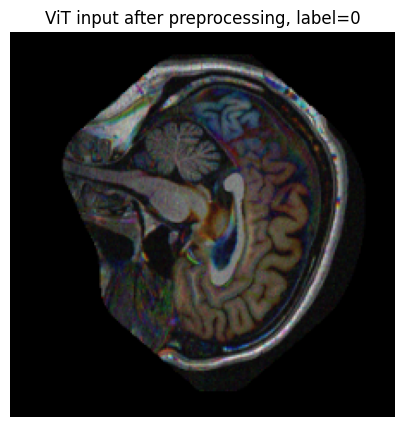

In [4]:
# Visual sanity check
import matplotlib.pyplot as plt

img, label = train_ds[0]
mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
std = torch.tensor(IMAGENET_STD).view(3,1,1)
display_img = (img * std + mean).clamp(0, 1)

plt.figure(figsize=(5,5))
plt.imshow(display_img.permute(1,2,0).numpy())
plt.title(f"ViT input after preprocessing, label={label.item()}")
plt.axis("off")
plt.show()

In [5]:
# Build ViT
import torch
import torch.nn as nn
from torchvision.models import vit_b_16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


model = vit_b_16(weights=None)

# Replace ImageNet's 1000-class head with our 2-class head
model.heads.head = nn.Linear(
    model.heads.head.in_features,
    2
)

model = model.to(device)

print("ViT created successfully")
print("Device:", device)
print("Final head:", model.heads.head)
print("Parameters:", sum(p.numel() for p in model.parameters()))

Using device: cuda
ViT created successfully
Device: cuda
Final head: Linear(in_features=768, out_features=2, bias=True)
Parameters: 85800194


In [6]:
# Sanity-check run (1 epoch, confirms everything end to end)
from torch.utils.data import DataLoader
import torch.optim as optim

BATCH_SIZE = 8  # ViT is heavier per-image than ResNet-50; raise to 16 if no OOM

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)  # lower LR than CNNs -- standard for ViT fine-tuning

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if training: optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

train_loss, train_acc = run_epoch(train_loader, training=True)
val_loss, val_acc = run_epoch(val_loader, training=False)
print(f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

train_loss=0.9629 train_acc=0.5488 | val_loss=0.6896 val_acc=0.5714


In [7]:
import torch
import torch.nn as nn
from torchvision.models import vit_b_16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

model = vit_b_16(weights=None)

model.heads.head = nn.Linear(
    model.heads.head.in_features,
    2
)

model = model.to(device)

print("ViT architecture loaded successfully")
print("Final head:", model.heads.head)
print(
    "Total parameters:",
    sum(p.numel() for p in model.parameters())
)

Using device: cuda
ViT architecture loaded successfully
Final head: Linear(in_features=768, out_features=2, bias=True)
Total parameters: 85800194


In [8]:
dummy = torch.randn(2, 3, 224, 224).to(device)

with torch.no_grad():
    output = model(dummy)

print("Input:", dummy.shape)
print("Output:", output.shape)

Input: torch.Size([2, 3, 224, 224])
Output: torch.Size([2, 2])


In [9]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the last encoder block + the head
for param in model.encoder.layers[-1].parameters():
    param.requires_grad = True
for param in model.heads.parameters():
    param.requires_grad = True

model.heads.head = nn.Linear(model.heads.head.in_features, 2)
model.heads.head.requires_grad_(True)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,} ({100*trainable/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 230MB/s]


Trainable: 7,089,410 / Total: 85,800,194 (8.3%)


In [10]:
import os

print("Kaggle input directories:")
for item in os.listdir("/kaggle/input"):
    print(" -", item)

Kaggle input directories:
 - datasets


In [11]:
print("\nAll dataset files/directories:")
for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")


All dataset files/directories:
input/
  datasets/
    mohanroyal273/


In [12]:
import os

base = "/kaggle/input/datasets/mohanroyal273"

print("Contents of:", base)

for item in os.listdir(base):
    path = os.path.join(base, item)
    print(
        "[DIR] " if os.path.isdir(path) else "[FILE]",
        item
    )

Contents of: /kaggle/input/datasets/mohanroyal273
[DIR]  neuroshield-oasis-model-b


In [13]:
import os

base = "/kaggle/input/datasets/mohanroyal273"

for root, dirs, files in os.walk(base):
    for f in files:
        if f.endswith((".hdr", ".img", ".csv")):
            print(os.path.join(root, f))
            break

/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b/oasis_model_ready.csv
/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b/splits/val.csv
/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b/data/disc11/OAS1_0418_MR1/RAW/OAS1_0418_MR1_mpr-1_anon.img
/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b/data/disc11/OAS1_0400_MR1/RAW/OAS1_0400_MR1_mpr-1_anon.hdr
/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b/data/disc11/OAS1_0405_MR1/RAW/OAS1_0405_MR1_mpr-1_anon.hdr
/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b/data/disc11/OAS1_0404_MR1/RAW/OAS1_0404_MR1_mpr-1_anon.img
/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b/data/disc11/OAS1_0398_MR1/RAW/OAS1_0398_MR1_mpr-1_anon.hdr
/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b/data/disc11/OAS1_0402_MR1/RAW/OAS1_0402_MR1_mpr-1_anon.img
/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b/data/disc11/OAS1_0390_MR1/RAW/OAS1_0390_MR

In [14]:
import os
import pandas as pd
from pathlib import Path

BASE = Path("/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b")

print("Dataset exists:", BASE.exists())
print("Dataset path:", BASE)

# Load fixed splits
train_df = pd.read_csv(BASE / "splits/train.csv")
val_df   = pd.read_csv(BASE / "splits/val.csv")
test_df  = pd.read_csv(BASE / "splits/test.csv")

print("\n=== SPLIT SIZES ===")
print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

print("\n=== TRAIN COLUMNS ===")
print(train_df.columns.tolist())

print("\n=== TRAIN HEAD ===")
display(train_df.head())

print("\n=== LABEL DISTRIBUTION ===")
if "label" in train_df.columns:
    print("Train:")
    print(train_df["label"].value_counts().sort_index())

    print("\nValidation:")
    print(val_df["label"].value_counts().sort_index())

    print("\nTest:")
    print(test_df["label"].value_counts().sort_index())

else:
    print("WARNING: 'label' column not found.")

print("\n=== RAW PATH EXAMPLE ===")
print(train_df.iloc[0]["scan_path"])

Dataset exists: True
Dataset path: /kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b

=== SPLIT SIZES ===
Train: 164
Val:   35
Test:  36
Total: 235

=== TRAIN COLUMNS ===
['ID', 'disc', 'scan_path', 'M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay', 'label']

=== TRAIN HEAD ===


,ID,disc,scan_path,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay,label
0,OAS1_0130_MR1,disc4,../../data/oasis/disc4/OAS1_0130_MR1/RAW/OAS1_...,M,R,68,3.0,3.0,26.0,0.0,1444,0.789,1.216,NaN,0
1,OAS1_0223_MR1,disc6,../../data/oasis/disc6/OAS1_0223_MR1/RAW/OAS1_...,M,R,84,2.0,NaN,20.0,1.0,1641,0.703,1.070,NaN,1
2,OAS1_0441_MR1,disc12,../../data/oasis/disc12/OAS1_0441_MR1/RAW/OAS1...,M,R,81,5.0,1.0,29.0,0.5,1647,0.721,1.066,NaN,1
3,OAS1_0404_MR1,disc11,../../data/oasis/disc11/OAS1_0404_MR1/RAW/OAS1...,F,R,73,2.0,2.0,29.0,0.0,1465,0.776,1.198,NaN,0
4,OAS1_0106_MR1,disc3,../../data/oasis/disc3/OAS1_0106_MR1/RAW/OAS1_...,F,R,81,2.0,4.0,30.0,0.0,1230,0.717,1.427,NaN,0



=== LABEL DISTRIBUTION ===
Train:
label
0    94
1    70
Name: count, dtype: int64

Validation:
label
0    20
1    15
Name: count, dtype: int64

Test:
label
0    21
1    15
Name: count, dtype: int64

=== RAW PATH EXAMPLE ===
../../data/oasis/disc4/OAS1_0130_MR1/RAW/OAS1_0130_MR1_mpr-1_anon.hdr


In [15]:
import os
import numpy as np
import pandas as pd

# --------------------------------------------------
# Track 1 OASIS Kaggle paths
# --------------------------------------------------
BASE = "/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b"

# Take the first training scan
row = train_df.iloc[0]

print("Subject:", row["ID"])
print("Label:", row["label"])
print("Original CSV path:")
print(row["scan_path"])

# --------------------------------------------------
# Convert local project path -> Kaggle path
# --------------------------------------------------
relative_path = row["scan_path"]

# Remove the original ../../data/oasis/ prefix
relative_path = relative_path.replace("../../data/oasis/", "")

hdr_path = os.path.join(BASE, "data", relative_path)

# .img has same path except extension
img_path = os.path.splitext(hdr_path)[0] + ".img"

print("\nKaggle HDR:")
print(hdr_path)

print("\nKaggle IMG:")
print(img_path)

print("\nHDR exists:", os.path.exists(hdr_path))
print("IMG exists:", os.path.exists(img_path))

if os.path.exists(hdr_path):
    print("HDR size:", os.path.getsize(hdr_path) / (1024**2), "MB")

if os.path.exists(img_path):
    print("IMG size:", os.path.getsize(img_path) / (1024**2), "MB")

Subject: OAS1_0130_MR1
Label: 0
Original CSV path:
../../data/oasis/disc4/OAS1_0130_MR1/RAW/OAS1_0130_MR1_mpr-1_anon.hdr

Kaggle HDR:
/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b/data/disc4/OAS1_0130_MR1/RAW/OAS1_0130_MR1_mpr-1_anon.hdr

Kaggle IMG:
/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b/data/disc4/OAS1_0130_MR1/RAW/OAS1_0130_MR1_mpr-1_anon.img

HDR exists: True
IMG exists: True
HDR size: 0.000331878662109375 MB
IMG size: 16.0 MB


In [16]:
!pip -q install nibabel

In [17]:
import nibabel as nib
import numpy as np

# Load the first OASIS MRI
img = nib.load(hdr_path)

print("Image object:", img)
print("Volume shape:", img.shape)
print("Data type:", img.get_data_dtype())

# Load voxel data
volume = img.get_fdata()

print("\n=== VOLUME INFORMATION ===")
print("Shape:", volume.shape)
print("Dtype:", volume.dtype)
print("Min:", np.min(volume))
print("Max:", np.max(volume))
print("Mean:", np.mean(volume))
print("Std:", np.std(volume))
print("Non-zero voxels:", np.count_nonzero(volume))

Image object: 
<class 'nibabel.spm2analyze.Spm2AnalyzeImage'>
data shape (256, 256, 128, 1)
affine:
[[  -1.       0.       0.     127.5  ]
 [   0.       1.       0.    -127.5  ]
 [   0.       0.       1.25   -79.375]
 [   0.       0.       0.       1.   ]]
metadata:
<class 'nibabel.spm2analyze.Spm2AnalyzeHeader'> object, endian='>'
sizeof_hdr     : 348
data_type      : b''
db_name        : b''
extents        : 16384
session_error  : 0
regular        : b'r'
hkey_un0       : b''
dim            : [  4 256 256 128   1   0   0   0]
vox_units      : b''
cal_units      : b''
unused1        : 0
datatype       : int16
bitpix         : 16
dim_un0        : 0
pixdim         : [0.   1.   1.   1.25 0.   0.   0.   0.  ]
vox_offset     : 0.0
scl_slope      : nan
scl_inter      : 0.0
funused3       : 0.0
cal_max        : 0.0
cal_min        : 0.0
compressed     : 0
verified       : 0
glmax          : 4095
glmin          : 0
descrip        : b'                                                             

In [18]:
def expand_scans_to_slices(df, offsets=(-30, -15, 0, 15, 30)):
    """Each row (one scan) becomes multiple rows (one per sagittal offset),
    all inheriting the same label and staying in the same split by construction --
    we're expanding an already-correctly-split dataframe, never re-splitting after."""
    rows = []
    for _, row in df.iterrows():
        for offset in offsets:
            new_row = row.copy()
            new_row["slice_offset"] = offset
            rows.append(new_row)
    return pd.DataFrame(rows).reset_index(drop=True)

train_expanded = expand_scans_to_slices(train_df)
val_expanded = expand_scans_to_slices(val_df)
test_expanded = expand_scans_to_slices(test_df)

print(f"Train: {len(train_df)} scans -> {len(train_expanded)} training examples")

# Leakage assertion -- run this every time, not just once
train_ids, val_ids, test_ids = set(train_df["ID"]), set(val_df["ID"]), set(test_df["ID"])
assert not (train_ids & val_ids), "LEAKAGE: subject in both train and val"
assert not (train_ids & test_ids), "LEAKAGE: subject in both train and test"
assert not (val_ids & test_ids), "LEAKAGE: subject in both val and test"
print("No subject leakage confirmed across splits.")

Train: 164 scans -> 820 training examples
No subject leakage confirmed across splits.


In [19]:
def normalize_mri_slice(stack):
    nonzero = stack[stack > 0]
    if len(nonzero) == 0:
        return stack
    p1, p99 = np.percentile(nonzero, [1, 99])
    stack = np.clip(stack, p1, p99)
    stack = (stack - p1) / (p99 - p1 + 1e-8)
    return np.clip(stack, 0, 1)

In [20]:
print(train_df.groupby("label")["Age"].agg(["mean", "std", "count"]))

            mean        std  count
label                             
0      68.872340  14.125577     94
1      76.514286   7.377488     70


In [21]:
# Corrected Dataset class: percentile normalization + multi-slice hippocampal coverage
import torch
from torch.utils.data import Dataset
import nibabel as nib
import numpy as np

IMG_SIZE = 224
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])
SLICE_OFFSETS = (-30, -15, 0, 15, 30)  # sagittal offsets from midline, covers hippocampal region

def expand_scans_to_slices(df, offsets=SLICE_OFFSETS):
    rows = []
    for _, row in df.iterrows():
        for offset in offsets:
            new_row = row.copy()
            new_row["slice_offset"] = offset
            rows.append(new_row)
    return pd.DataFrame(rows).reset_index(drop=True)

def normalize_mri_slice(stack):
    nonzero = stack[stack > 0]
    if len(nonzero) == 0:
        return stack
    p1, p99 = np.percentile(nonzero, [1, 99])
    stack = np.clip(stack, p1, p99)
    stack = (stack - p1) / (p99 - p1 + 1e-8)
    return np.clip(stack, 0, 1)

class OASISViTDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        volume = nib.load(row["scan_path"]).get_fdata().squeeze()  # (256, 256, 128)

        mid = volume.shape[2] // 2
        center = mid + int(row["slice_offset"])
        center = max(1, min(volume.shape[2] - 2, center))  # keep 3-slice window in bounds

        stack = volume[:, :, center-1:center+2]
        stack = np.transpose(stack, (2, 0, 1)).astype(np.float32)  # (3, 256, 256)
        stack = normalize_mri_slice(stack)

        tensor = torch.from_numpy(stack).unsqueeze(0)
        tensor = torch.nn.functional.interpolate(tensor, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        tensor = tensor.squeeze(0)

        mean = torch.tensor(IMAGENET_MEAN, dtype=torch.float32).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD, dtype=torch.float32).view(3, 1, 1)
        tensor = (tensor - mean) / std

        label = torch.tensor(row["label"], dtype=torch.long)
        return tensor, label, row["ID"]  # ID included for scan-level aggregation later

print("Dataset class ready.")

Dataset class ready.


In [22]:
KAGGLE_BASE = "/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b"

def fix_scan_path(path):
    path = str(path)

    if path.startswith("/kaggle/input"):
        return path

    prefix = "../../data/oasis/"
    if path.startswith(prefix):
        relative = path[len(prefix):]
        return f"{KAGGLE_BASE}/data/{relative}"

    return path


# Fix paths in the expanded dataframes
train_expanded["scan_path"] = train_expanded["scan_path"].apply(fix_scan_path)
val_expanded["scan_path"] = val_expanded["scan_path"].apply(fix_scan_path)
test_expanded["scan_path"] = test_expanded["scan_path"].apply(fix_scan_path)

# Verify
print(train_expanded["scan_path"].iloc[0])
print("Exists:", os.path.exists(train_expanded["scan_path"].iloc[0]))

/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b/data/disc4/OAS1_0130_MR1/RAW/OAS1_0130_MR1_mpr-1_anon.hdr
Exists: True


In [23]:
train_ds = OASISViTDataset(train_expanded)
val_ds = OASISViTDataset(val_expanded)
test_ds = OASISViTDataset(test_expanded)

img, label, sid = train_ds[0]

print("Tensor shape:", img.shape)
print("Label:", label.item())
print("Subject:", sid)

Tensor shape: torch.Size([3, 224, 224])
Label: 0
Subject: OAS1_0130_MR1


# 1. Dataset & Preprocessing


In [24]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset

KAGGLE_BASE = "/kaggle/input/datasets/mohanroyal273/neuroshield-oasis-model-b"
IMG_SIZE = 224
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])
SLICE_OFFSETS = (-30, -15, 0, 15, 30)

# --- 1. Load splits fresh ---
train_df = pd.read_csv(f"{KAGGLE_BASE}/splits/train.csv")
val_df = pd.read_csv(f"{KAGGLE_BASE}/splits/val.csv")
test_df = pd.read_csv(f"{KAGGLE_BASE}/splits/test.csv")

# --- 2. Fix paths (always, unconditionally, every session) ---
def fix_scan_path(old_path):
    parts = old_path.replace("\\", "/").split("/")
    disc_idx = next(i for i, p in enumerate(parts) if p.startswith("disc"))
    relative = "/".join(parts[disc_idx:])
    return f"{KAGGLE_BASE}/data/{relative}"

for df in [train_df, val_df, test_df]:
    df["scan_path"] = df["scan_path"].apply(fix_scan_path)

# Hard assertion, not just a print -- this stops execution immediately if paths are wrong,
# instead of failing 3 cells later inside a DataLoader with a confusing traceback.
assert os.path.exists(train_df["scan_path"].iloc[0]), \
    f"Path fix failed: {train_df['scan_path'].iloc[0]} does not exist"
print("Paths verified correct for this session.")

# --- 3. Leakage check ---
train_ids, val_ids, test_ids = set(train_df["ID"]), set(val_df["ID"]), set(test_df["ID"])
assert not (train_ids & val_ids) and not (train_ids & test_ids) and not (val_ids & test_ids)
print("No subject leakage confirmed.")

# --- 4. Expand to multi-slice, normalize, dataset class ---
def expand_scans_to_slices(df, offsets=SLICE_OFFSETS):
    rows = []
    for _, row in df.iterrows():
        for offset in offsets:
            new_row = row.copy()
            new_row["slice_offset"] = offset
            rows.append(new_row)
    return pd.DataFrame(rows).reset_index(drop=True)

def normalize_mri_slice(stack):
    nonzero = stack[stack > 0]
    if len(nonzero) == 0:
        return stack
    p1, p99 = np.percentile(nonzero, [1, 99])
    stack = np.clip(stack, p1, p99)
    stack = (stack - p1) / (p99 - p1 + 1e-8)
    return np.clip(stack, 0, 1)

class OASISViTDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        import nibabel as nib
        row = self.df.iloc[idx]
        volume = nib.load(row["scan_path"]).get_fdata().squeeze()

        mid = volume.shape[2] // 2
        center = mid + int(row["slice_offset"])
        center = max(1, min(volume.shape[2] - 2, center))

        stack = volume[:, :, center-1:center+2]
        stack = np.transpose(stack, (2, 0, 1)).astype(np.float32)
        stack = normalize_mri_slice(stack).astype(np.float32)
        tensor = torch.from_numpy(stack).unsqueeze(0)
        tensor = torch.nn.functional.interpolate(tensor, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        tensor = tensor.squeeze(0)

        mean = torch.tensor(IMAGENET_MEAN, dtype=torch.float32).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD, dtype=torch.float32).view(3, 1, 1)
        tensor = (tensor - mean) / std

        label = torch.tensor(row["label"], dtype=torch.long)
        return tensor, label, row["ID"]

def collate_fn(batch):
    imgs = torch.stack([b[0] for b in batch])
    labels = torch.stack([b[1] for b in batch])
    ids = [b[2] for b in batch]
    return imgs, labels, ids

train_expanded = expand_scans_to_slices(train_df)
val_expanded = expand_scans_to_slices(val_df)
test_expanded = expand_scans_to_slices(test_df)

train_ds = OASISViTDataset(train_expanded)
val_ds = OASISViTDataset(val_expanded)
test_ds = OASISViTDataset(test_expanded)

print(f"Train: {len(train_df)} scans -> {len(train_expanded)} examples")
print(f"Val:   {len(val_df)} scans -> {len(val_expanded)} examples")
print(f"Test:  {len(test_df)} scans -> {len(test_expanded)} examples")

img, label, sid = train_ds[0]
print(f"Sample check -- shape: {img.shape}, label: {label.item()}, subject: {sid}")

Paths verified correct for this session.
No subject leakage confirmed.
Train: 164 scans -> 820 examples
Val:   35 scans -> 175 examples
Test:  36 scans -> 180 examples
Sample check -- shape: torch.Size([3, 224, 224]), label: 0, subject: OAS1_0130_MR1


# 2. Model Architecture


In [25]:
# Model builder (function, so each seed gets a fresh model)
import torch.nn as nn
from torchvision.models import vit_b_16, ViT_B_16_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def build_model():
    model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.encoder.layers[-1].parameters():
        param.requires_grad = True
    model.heads.head = nn.Linear(model.heads.head.in_features, 2)
    for param in model.heads.parameters():
        param.requires_grad = True
    return model.to(device)

_test_model = build_model()
trainable = sum(p.numel() for p in _test_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in _test_model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
del _test_model

Using device: cuda
Trainable: 7,089,410 / 85,800,194 (8.3%)


# 3. Sanity Overfit Test


In [26]:
# Single-batch overfit sanity check
from torch.utils.data import DataLoader, Subset
import torch.optim as optim

def collate_fn(batch):
    imgs = torch.stack([b[0] for b in batch])
    labels = torch.stack([b[1] for b in batch])
    ids = [b[2] for b in batch]
    return imgs, labels, ids

sanity_model = build_model()
tiny_loader = DataLoader(Subset(train_ds, range(12)), batch_size=4, shuffle=True, collate_fn=collate_fn)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, sanity_model.parameters()), lr=1e-4)

for epoch in range(20):
    sanity_model.train()
    correct, total, total_loss = 0, 0, 0
    for images, labels, _ in tiny_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = sanity_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    if epoch % 5 == 0:
        print(f"epoch {epoch}: loss={total_loss/total:.4f} acc={correct/total:.4f}")

print("\nExpect acc -> 1.0 well before epoch 20. If it doesn't, stop and tell me before proceeding.")
del sanity_model

epoch 0: loss=0.6433 acc=0.5833
epoch 5: loss=0.0357 acc=1.0000
epoch 10: loss=0.0032 acc=1.0000
epoch 15: loss=0.0009 acc=1.0000

Expect acc -> 1.0 well before epoch 20. If it doesn't, stop and tell me before proceeding.


# 4. Training


In [27]:
# Full multi-seed training with early stopping and scan-level validation
import random

SEEDS = [42, 123, 2024]
NUM_EPOCHS = 30
PATIENCE = 5
BATCH_SIZE = 16

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def run_epoch(model, loader, criterion, optimizer, training):
    model.train() if training else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(training):
        for images, labels, _ in loader:
            images, labels = images.to(device), labels.to(device)
            if training: optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

def scan_level_accuracy(model, loader):
    """Aggregates multiple slice predictions per scan into one prediction per scan,
    via averaged softmax -- this is the metric that actually matters, not raw slice accuracy."""
    model.eval()
    scan_probs = {}
    scan_labels = {}
    with torch.no_grad():
        for images, labels, ids in loader:
            images = images.to(device)
            probs = torch.softmax(model(images), dim=1).cpu().numpy()
            for i, sid in enumerate(ids):
                scan_probs.setdefault(sid, []).append(probs[i])
                scan_labels[sid] = labels[i].item()
    correct = 0
    for sid, probs_list in scan_probs.items():
        avg_prob = np.mean(probs_list, axis=0)
        pred = np.argmax(avg_prob)
        correct += int(pred == scan_labels[sid])
    return correct / len(scan_probs)

def train_one_seed(seed):
    set_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)

    model = build_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

    best_val_loss = float("inf")
    epochs_no_improve = 0
    ckpt_path = f"/kaggle/working/model_b_vit_seed{seed}_best.pt"

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, training=True)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer, training=False)
        scan_acc = scan_level_accuracy(model, val_loader)
        scheduler.step(val_loss)

        print(f"[seed {seed}] epoch {epoch+1}: train_acc={train_acc:.4f} "
              f"val_slice_acc={val_acc:.4f} val_scan_acc={scan_acc:.4f} val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"[seed {seed}] early stopping at epoch {epoch+1}")
                break

    return ckpt_path

checkpoint_paths = {}
for seed in SEEDS:
    checkpoint_paths[seed] = train_one_seed(seed)

print("\nAll seeds complete:", checkpoint_paths)

[seed 42] epoch 1: train_acc=0.5951 val_slice_acc=0.6229 val_scan_acc=0.5714 val_loss=0.6636
[seed 42] epoch 2: train_acc=0.6378 val_slice_acc=0.6343 val_scan_acc=0.5714 val_loss=0.6532
[seed 42] epoch 3: train_acc=0.6585 val_slice_acc=0.6286 val_scan_acc=0.6286 val_loss=0.6461
[seed 42] epoch 4: train_acc=0.6768 val_slice_acc=0.6457 val_scan_acc=0.6286 val_loss=0.6320
[seed 42] epoch 5: train_acc=0.7098 val_slice_acc=0.6914 val_scan_acc=0.7143 val_loss=0.6306
[seed 42] epoch 6: train_acc=0.7085 val_slice_acc=0.6171 val_scan_acc=0.6286 val_loss=0.6376
[seed 42] epoch 7: train_acc=0.7146 val_slice_acc=0.6971 val_scan_acc=0.7714 val_loss=0.6336
[seed 42] epoch 8: train_acc=0.7146 val_slice_acc=0.7029 val_scan_acc=0.6571 val_loss=0.6204
[seed 42] epoch 9: train_acc=0.7256 val_slice_acc=0.6743 val_scan_acc=0.6286 val_loss=0.6259
[seed 42] epoch 10: train_acc=0.7488 val_slice_acc=0.6343 val_scan_acc=0.6000 val_loss=0.6353
[seed 42] epoch 11: train_acc=0.7732 val_slice_acc=0.6286 val_scan_ac

# 5. Final Test Evaluation


In [28]:
# Full test-set evaluation, per seed, all metrics, scan-level
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

def evaluate_on_test(model, loader):
    model.eval()
    scan_probs, scan_labels = {}, {}
    with torch.no_grad():
        for images, labels, ids in loader:
            images = images.to(device)
            probs = torch.softmax(model(images), dim=1).cpu().numpy()
            for i, sid in enumerate(ids):
                scan_probs.setdefault(sid, []).append(probs[i])
                scan_labels[sid] = labels[i].item()

    y_true, y_pred, y_score = [], [], []
    for sid, probs_list in scan_probs.items():
        avg_prob = np.mean(probs_list, axis=0)
        y_true.append(scan_labels[sid])
        y_pred.append(int(np.argmax(avg_prob)))
        y_score.append(avg_prob[1])

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "sensitivity_recall": recall_score(y_true, y_pred),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
        "confusion_matrix": cm.tolist(),
        "n_scans": len(y_true),
    }

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)

all_results = {}
for seed, ckpt_path in checkpoint_paths.items():
    model = build_model()
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    results = evaluate_on_test(model, test_loader)
    all_results[seed] = results
    print(f"\n--- Seed {seed} (test set, {results['n_scans']} scans) ---")
    for k, v in results.items():
        if k != "confusion_matrix":
            print(f"  {k}: {v:.4f}")
    print(f"  confusion_matrix: {results['confusion_matrix']}")


--- Seed 42 (test set, 36 scans) ---
  accuracy: 0.7222
  balanced_accuracy: 0.7238
  sensitivity_recall: 0.7333
  specificity: 0.7143
  f1: 0.6875
  roc_auc: 0.7302
  n_scans: 36.0000
  confusion_matrix: [[15, 6], [4, 11]]

--- Seed 123 (test set, 36 scans) ---
  accuracy: 0.7222
  balanced_accuracy: 0.7238
  sensitivity_recall: 0.7333
  specificity: 0.7143
  f1: 0.6875
  roc_auc: 0.7556
  n_scans: 36.0000
  confusion_matrix: [[15, 6], [4, 11]]

--- Seed 2024 (test set, 36 scans) ---
  accuracy: 0.6944
  balanced_accuracy: 0.6905
  sensitivity_recall: 0.6667
  specificity: 0.7143
  f1: 0.6452
  roc_auc: 0.7302
  n_scans: 36.0000
  confusion_matrix: [[15, 6], [5, 10]]


# 6. Final Results


In [29]:
# Mean ± std across seeds (final Model B result)
metrics_to_summarize = ["accuracy", "balanced_accuracy", "sensitivity_recall", "specificity", "f1", "roc_auc"]

print("=== Model B (ViT-B/16) — Test Set Results, Mean ± Std Across 3 Seeds ===\n")
summary = {}
for metric in metrics_to_summarize:
    values = [all_results[seed][metric] for seed in SEEDS]
    mean, std = np.mean(values), np.std(values)
    summary[metric] = (mean, std)
    print(f"{metric:22s}: {mean:.4f} ± {std:.4f}")

majority_baseline = max(train_df["label"].value_counts(normalize=True))
print(f"\nMajority-class baseline for reference: {majority_baseline:.4f}")
print("If mean accuracy sits at or below this line, the model has not demonstrated real learning yet.")

=== Model B (ViT-B/16) — Test Set Results, Mean ± Std Across 3 Seeds ===

accuracy              : 0.7130 ± 0.0131
balanced_accuracy     : 0.7127 ± 0.0157
sensitivity_recall    : 0.7111 ± 0.0314
specificity           : 0.7143 ± 0.0000
f1                    : 0.6734 ± 0.0200
roc_auc               : 0.7386 ± 0.0120

Majority-class baseline for reference: 0.5732
If mean accuracy sits at or below this line, the model has not demonstrated real learning yet.


# 7. Saved Artifacts & Configuration


In [30]:
# Save the Model B results
import json
import pandas as pd

# Save per-seed results
results_rows = []

for seed, result in all_results.items():
    row = {
        "seed": seed,
        "accuracy": result["accuracy"],
        "balanced_accuracy": result["balanced_accuracy"],
        "sensitivity_recall": result["sensitivity_recall"],
        "specificity": result["specificity"],
        "f1": result["f1"],
        "roc_auc": result["roc_auc"],
        "n_scans": result["n_scans"],
        "confusion_matrix": result["confusion_matrix"]
    }
    results_rows.append(row)

results_df = pd.DataFrame(results_rows)

results_df.to_csv(
    "/kaggle/working/model_b_vit_results_per_seed.csv",
    index=False
)

print(results_df)
print("\nSaved:")
print("/kaggle/working/model_b_vit_results_per_seed.csv")

   seed  accuracy  balanced_accuracy  sensitivity_recall  specificity  \
0    42  0.722222           0.723810            0.733333     0.714286   
1   123  0.722222           0.723810            0.733333     0.714286   
2  2024  0.694444           0.690476            0.666667     0.714286   

         f1   roc_auc  n_scans    confusion_matrix  
0  0.687500  0.730159       36  [[15, 6], [4, 11]]  
1  0.687500  0.755556       36  [[15, 6], [4, 11]]  
2  0.645161  0.730159       36  [[15, 6], [5, 10]]  

Saved:
/kaggle/working/model_b_vit_results_per_seed.csv


In [31]:
summary_rows = []

for metric, (mean, std) in summary.items():
    summary_rows.append({
        "metric": metric,
        "mean": mean,
        "std": std
    })

summary_df = pd.DataFrame(summary_rows)

summary_df.to_csv(
    "/kaggle/working/model_b_vit_results_summary.csv",
    index=False
)

print(summary_df)

               metric      mean       std
0            accuracy  0.712963  0.013095
1   balanced_accuracy  0.712698  0.015713
2  sensitivity_recall  0.711111  0.031427
3         specificity  0.714286  0.000000
4                  f1  0.673387  0.019959
5             roc_auc  0.738624  0.011972


In [32]:
# Save the experiment configuration
config = {
    "model": "ViT-B/16",
    "pretrained": "ImageNet1K_V1",
    "trainable_components": "last encoder block + classification head",
    "trainable_parameters": 7089410,
    "total_parameters": 85800194,
    "slice_offsets": [-30, -15, 0, 15, 30],
    "input_size": [224, 224],
    "normalization": "non-zero voxel percentile 1-99 + ImageNet mean/std",
    "train_scans": 164,
    "validation_scans": 35,
    "test_scans": 36,
    "training_examples": 820,
    "validation_examples": 175,
    "test_examples": 180,
    "seeds": [42, 123, 2024],
    "decision_rule": "argmax softmax probability",
    "test_evaluation": "scan-level; mean probability across five slice offsets"
}

with open(
    "/kaggle/working/model_b_vit_config.json",
    "w"
) as f:
    json.dump(config, f, indent=2)

print("Configuration saved.")

Configuration saved.


# 8. Experiment Summary


# 8. Experiment Summary

This notebook documents the finalized NeuroShield Track 1 Model B experiment using a ViT-B/16 classifier on the OASIS dataset.

The experiment includes:
- Fixed train/validation/test splits
- 2.5D multi-slice MRI preprocessing
- ImageNet-pretrained ViT-B/16
- 12-example overfit sanity test
- Three-seed training (42, 123, 2024)
- Scan-level held-out test evaluation
- Saved per-seed results, summary results, and experiment configuration